# Seasonal + Lag Analysis of Oil, Gas, and Brine Production
# Using well distances + quarterly production

This notebook analyzes how seasonal patterns and temporal dynamics in oil and gas production relate to well proximity to saltwater injection wells (SWIWs). It begins by loading the cleaned production, permit, and distance datasets, merging them into a unified quarterly dataset. After preparing quarter and year indicators, the workflow constructs seasonal categories to evaluate statewide production patterns across winter, spring, summer, and fall. The notebook visualizes these patterns for oil, gas, and brine, and then investigates how seasonal production varies by distance group relative to the nearest SWIW. Building on this, the analysis transitions into a time-series framework by creating lagged production variables over 1-, 4-, 8-, and 12-quarter intervals to measure delayed effects. Multiple OLS regression models estimate how previous production levels and SWIW proximity jointly influence current oil production. The notebook concludes with a combined lag model and a comparative table of R², AIC, and coefficient magnitudes across lag lengths, along with visualizations showing how model performance and estimated effects evolve with longer temporal lags.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
from shapely.geometry import Point

plt.style.use('seaborn-v0_8')

### Load Data

In [15]:
# Load well information
well_info = pd.read_csv('../data/final/well_information_final.csv')

# Load permit list (includes SWIW wells)
permits = pd.read_csv('../data/final/permit_plug_list_final.csv')

# Load nearest saltwater distances
nearest_saltwater = pd.read_csv('../data/distance/well_to_nearest_saltwater_updated.csv')

# Load quarterly production (your combined production dataset)
quarterly_prod = pd.read_csv('../data/final/quarterly_production_final.csv')

annual_prod = pd.read_csv('../data/final/annual_production_final.csv')

### Prepare the Dataset

In [21]:
# Merge production with distances
df = quarterly_prod.merge(
    nearest_saltwater[['API WELL NUMBER', 'Nearest_SWIW_km']],
    left_on='API Number',
    right_on='API WELL NUMBER',
    how='left'
)

df_ann = annual_prod.merge(
    nearest_saltwater[['API WELL NUMBER', 'Nearest_SWIW_km']],
    left_on='API Number',
    right_on='API WELL NUMBER',
    how='left'
)

### Add Seasonal Indicators

In [4]:
# Fix quarter column (convert to number)
df['Quarter'] = pd.to_numeric(df['Quarter (1, 2, 3, 4, n/a)'], errors='coerce')

# Year from production year column
df['Year'] = df['Production Year']

# Map quarters to seasons
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
df['Season'] = df['Quarter'].map(season_map)

### Seasonal Production Patterns (Statewide)

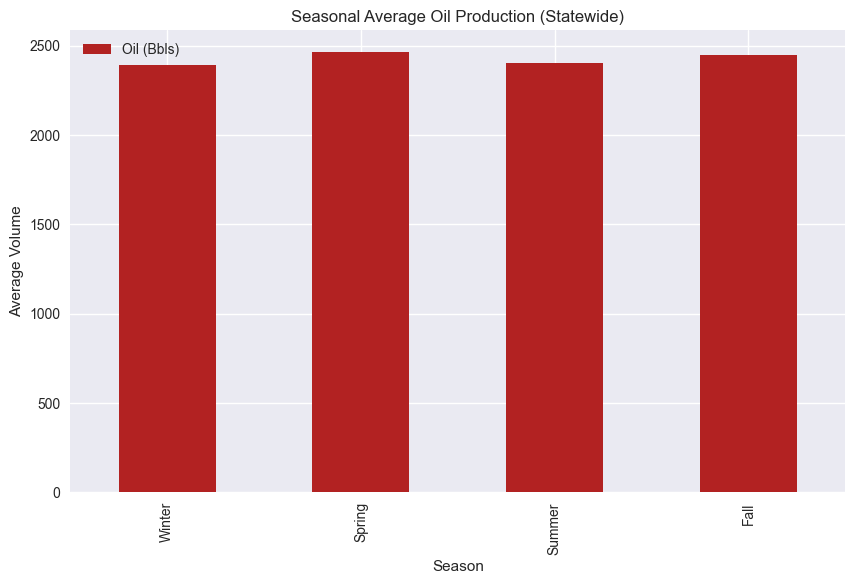

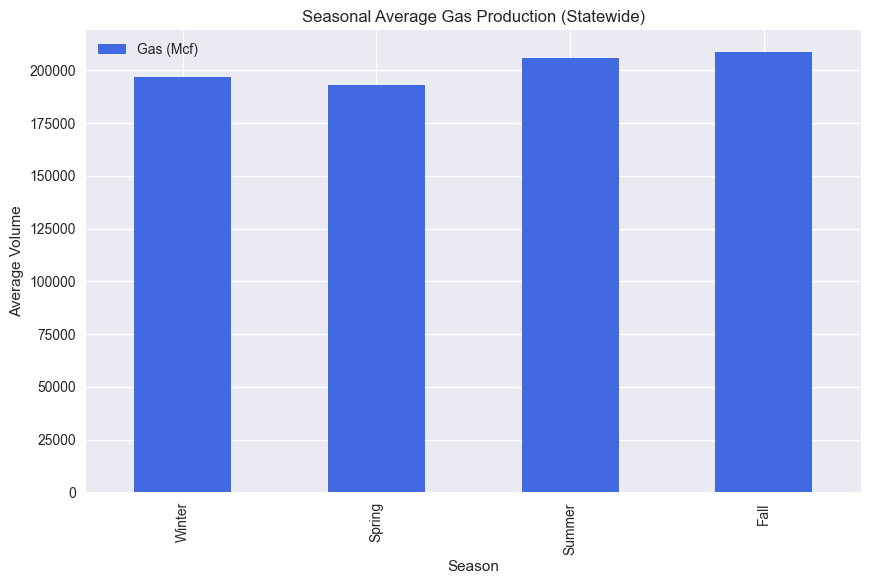

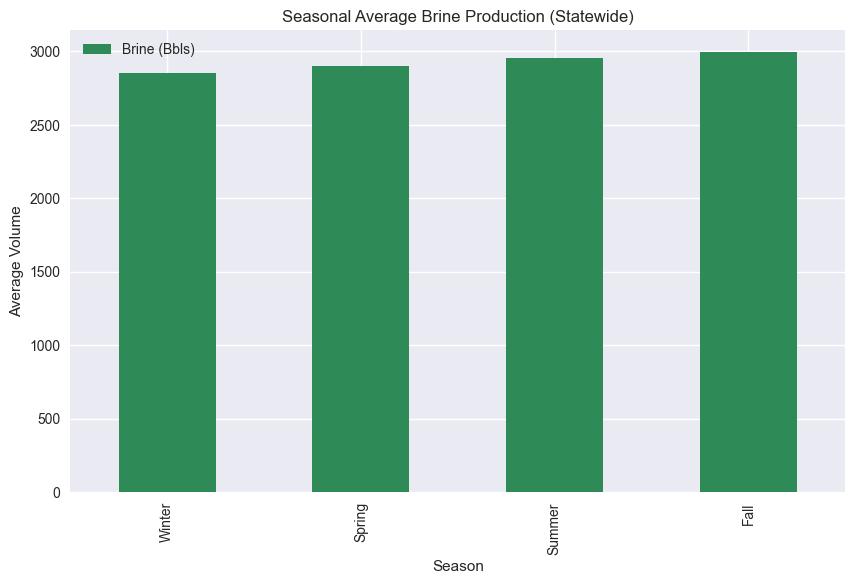

Seasonal Production Summary Table:


,Avg_Oil_Bbls,Avg_Gas_Mcf,Avg_Brine_Bbls
Season,,,
Winter,2388.981176,196970.020666,2851.101783
Spring,2462.362668,192870.743661,2899.388344
Summer,2402.521250,205968.320962,2953.428677
Fall,2446.682134,208477.161020,2993.964715


In [5]:
# Compute seasonal averages
seasonal_summary = (
    df.groupby(['Season'])[['Oil (Bbls)', 'Gas (Mcf)', 'Brine (Bbls)']]
      .mean()
      .reindex(['Winter', 'Spring', 'Summer', 'Fall'])
)

# Oil
seasonal_summary[['Oil (Bbls)']].plot(
    kind='bar',
    figsize=(10,6),
    color='firebrick'
)
plt.title("Seasonal Average Oil Production (Statewide)")
plt.ylabel("Average Volume")
plt.show()

# Gas
seasonal_summary[['Gas (Mcf)']].plot(
    kind='bar',
    figsize=(10,6),
    color='royalblue'
)
plt.title("Seasonal Average Gas Production (Statewide)")
plt.ylabel("Average Volume")
plt.show()

# Brine
seasonal_summary[['Brine (Bbls)']].plot(
    kind='bar',
    figsize=(10,6),
    color='seagreen'
)
plt.title("Seasonal Average Brine Production (Statewide)")
plt.ylabel("Average Volume")
plt.show()

seasonal_summary_table = seasonal_summary.copy()
seasonal_summary_table.columns = ['Avg_Oil_Bbls', 'Avg_Gas_Mcf', 'Avg_Brine_Bbls']

print("Seasonal Production Summary Table:")
display(seasonal_summary_table)


### Seasonal Patterns by Distance-to-SWIW Group

C:\Users\willf\AppData\Local\Temp\ipykernel_15756\3519007374.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=

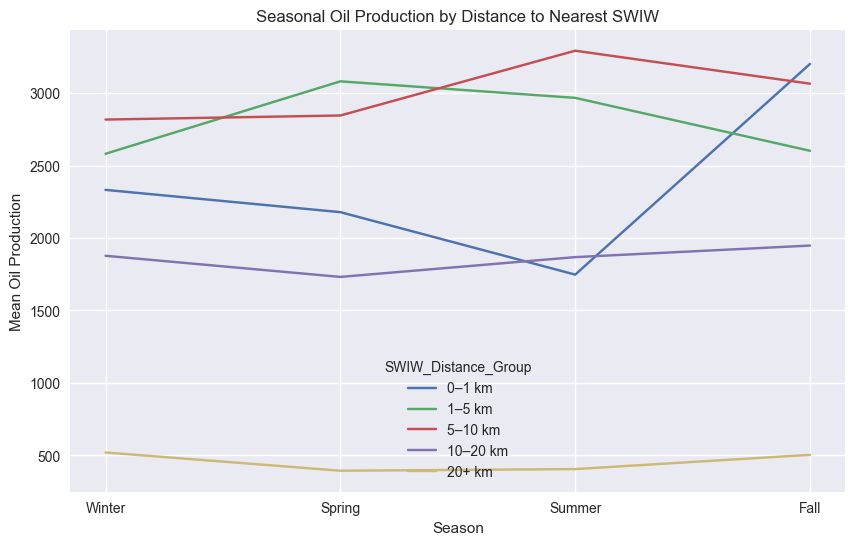

In [ ]:
bins = [0, 1, 5, 10, 20, 1000]
labels = ['0-1 km', '1-5 km', '5-10 km', '10-20 km', '20+ km']

df['SWIW_Distance_Group'] = pd.cut(
    df['Nearest_SWIW_km'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=df, 
    x='Season', 
    y='Oil (Bbls)', 
    hue='SWIW_Distance_Group',
    estimator='mean',
    ci=None
)
plt.title("Seasonal Oil Production by Distance to Nearest SWIW")
plt.ylabel("Mean Oil Production")
plt.show()

### Prepare Data for Lag Analysis

In [7]:
df['Quarter'] = df['Quarter (1, 2, 3, 4, n/a)'].replace('n/a', pd.NA).astype(float)

# Create Period String
df['Period'] = (
    df['Production Year'].astype(int).astype(str)
    + 'Q'
    + df['Quarter'].fillna(1).astype(int).astype(str)
)
df['DATE'] = pd.PeriodIndex(df['Period'], freq='Q').to_timestamp()

df = df.sort_values(['API Number', 'DATE'])

df['DATE'] = pd.PeriodIndex(df['Period'], freq='Q').to_timestamp()
df['Oil_lag1']  = df.groupby('API Number')['Oil (Bbls)'].shift(1)   # one quarter
df['Oil_lag4']  = df.groupby('API Number')['Oil (Bbls)'].shift(4)   # one year
df['Oil_lag8']  = df.groupby('API Number')['Oil (Bbls)'].shift(8)   # two years
df['Oil_lag12'] = df.groupby('API Number')['Oil (Bbls)'].shift(12)  # three years

In [37]:
df_ann = df_ann[df_ann['Nearest_SWIW_km'] <= 5]

bad_prod_wells = (
    df_ann
    .groupby('API Number')['Oil (Bbls)']
    .mean()
    .loc[lambda s: s > 200]
    .index
    .tolist()
)

bad_prod_wells_2 = (
    df_ann
    .groupby('API Number')['Gas (Mcf)']
    .mean()
    .loc[lambda s: s > 1000]
    .index
    .tolist()
)

zero_wells = (
    df_ann
    .groupby('API Number')['Gas (Mcf)']
    .min()
    .loc[lambda s: s == 0]
    .index
    .tolist()
)

zero_wells_2 = (
    df_ann
    .groupby('API Number')['Oil (Bbls)']
    .min()
    .loc[lambda s: s == 0]
    .index
    .tolist()
)

df_ann_fil = df_ann[
    (df_ann['API Number'].isin(bad_prod_wells)) |
    (df_ann['API Number'].isin(bad_prod_wells_2)) | 
    (df_ann['API Number'].isin(zero_wells)) |
    (df_ann['API Number'].isin(zero_wells_2))
]

df_ann_fil['DATE'] = pd.PeriodIndex(df_ann_fil['Production Year'], freq='Y').to_timestamp()
df_ann_fil = df_ann_fil.sort_values(['API Number', 'DATE'])
df_ann_fil['Oil_lag1'] = df_ann_fil.groupby('API Number')['Oil (Bbls)'].shift(1)   # one quarter
df_ann_fil['Oil_lag2'] = df_ann_fil.groupby('API Number')['Oil (Bbls)'].shift(2)   # one year
df_ann_fil['Oil_lag3'] = df_ann_fil.groupby('API Number')['Oil (Bbls)'].shift(3)   # two years
df_ann_fil['Oil_lag4'] = df_ann_fil.groupby('API Number')['Oil (Bbls)'].shift(4)  # three years
df_ann_fil['Gas_lag1'] = df_ann_fil.groupby('API Number')['Gas (Mcf)'].shift(1)   # one quarter
df_ann_fil['Gas_lag2'] = df_ann_fil.groupby('API Number')['Gas (Mcf)'].shift(2)   # one year
df_ann_fil['Gas_lag3'] = df_ann_fil.groupby('API Number')['Gas (Mcf)'].shift(3)   # two years
df_ann_fil['Gas_lag4'] = df_ann_fil.groupby('API Number')['Gas (Mcf)'].shift(4)  # three years

C:\Users\willf\AppData\Local\Temp\ipykernel_15756\3745343094.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ann_fil['DATE'] = pd.PeriodIndex(df_ann_fil['Production Year'], freq='Y').to_timestamp()


### Lag Regression

In [82]:
import statsmodels.api as sm

lag_df = df_ann_fil.dropna(subset=[
    'Oil (Bbls)', 
    'Oil_lag1', 
    'Oil_lag2', 
    'Oil_lag3', 
    'Oil_lag4',
    'Gas (Mcf)',
    'Gas_lag1', 
    'Gas_lag2', 
    'Gas_lag3', 
    'Gas_lag4',
    'Nearest_SWIW_km'
])

X1 = lag_df[['Oil_lag1']]
X1 = sm.add_constant(X1)
y  = lag_df['Oil (Bbls)']

model1 = sm.OLS(y, X1).fit()
print("\n===== LAG-1 MODEL =====")
print(model1.summary())


===== LAG-1 MODEL =====
                            OLS Regression Results                            
Dep. Variable:             Oil (Bbls)   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                 5.228e+05
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:06:36   Log-Likelihood:            -8.0745e+05
No. Observations:              137681   AIC:                         1.615e+06
Df Residuals:                  137679   BIC:                         1.615e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.1258      

In [83]:
X4 = lag_df[['Oil_lag2']]
X4 = sm.add_constant(X4)

model4 = sm.OLS(y, X4).fit()
print("\n===== LAG-4 MODEL =====")
print(model4.summary())


===== LAG-4 MODEL =====
                            OLS Regression Results                            
Dep. Variable:             Oil (Bbls)   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.584
Method:                 Least Squares   F-statistic:                 1.931e+05
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:06:38   Log-Likelihood:            -8.5506e+05
No. Observations:              137681   AIC:                         1.710e+06
Df Residuals:                  137679   BIC:                         1.710e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.6711      

In [84]:
X8 = lag_df[['Oil_lag3']]
X8 = sm.add_constant(X8)

model8 = sm.OLS(y, X8).fit()
print("\n===== LAG-8 MODEL =====")
print(model8.summary())


===== LAG-8 MODEL =====
                            OLS Regression Results                            
Dep. Variable:             Oil (Bbls)   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                 9.316e+04
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:06:40   Log-Likelihood:            -8.7982e+05
No. Observations:              137681   AIC:                         1.760e+06
Df Residuals:                  137679   BIC:                         1.760e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.0962      

In [85]:
X12 = lag_df[['Oil_lag4']]
X12 = sm.add_constant(X12)

model12 = sm.OLS(y, X12).fit()
print("\n===== LAG-12 MODEL =====")
print(model12.summary())


===== LAG-12 MODEL =====
                            OLS Regression Results                            
Dep. Variable:             Oil (Bbls)   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                 8.380e+04
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:06:42   Log-Likelihood:            -8.8267e+05
No. Observations:              137681   AIC:                         1.765e+06
Df Residuals:                  137679   BIC:                         1.765e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.6692     

### Combined Models

In [86]:
Xall = lag_df[['Oil_lag1','Oil_lag2','Oil_lag3','Oil_lag4']]
Xall = sm.add_constant(Xall)

combined_model = sm.OLS(y, Xall).fit()
print("\n===== COMBINED MODEL (LAG 1, 4, 8, 12) =====")
print(combined_model.summary())

comparison_table = pd.DataFrame({
    "Model": ["Lag 1","Lag 4","Lag 8","Lag 12","Combined"],
    "R_squared": [
        model1.rsquared,
        model4.rsquared,
        model8.rsquared,
        model12.rsquared,
        combined_model.rsquared
    ],
    "AIC": [
        model1.aic,
        model4.aic,
        model8.aic,
        model12.aic,
        combined_model.aic
    ],
    "Lag_Coefficient": [
        model1.params['Oil_lag1'],
        model4.params['Oil_lag2'],
        model8.params['Oil_lag3'],
        model12.params['Oil_lag4'],
        None 
    ],
    "Lag_SE": [
        model1.bse['Oil_lag1'],
        model4.bse['Oil_lag2'],
        model8.bse['Oil_lag3'],
        model12.bse['Oil_lag4'],
        None
    ]
})

print("\n===== MODEL COMPARISON TABLE =====")
print(comparison_table)


===== COMBINED MODEL (LAG 1, 4, 8, 12) =====
                            OLS Regression Results                            
Dep. Variable:             Oil (Bbls)   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                 1.387e+05
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:06:45   Log-Likelihood:            -8.0418e+05
No. Observations:              137681   AIC:                         1.608e+06
Df Residuals:                  137676   BIC:                         1.608e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

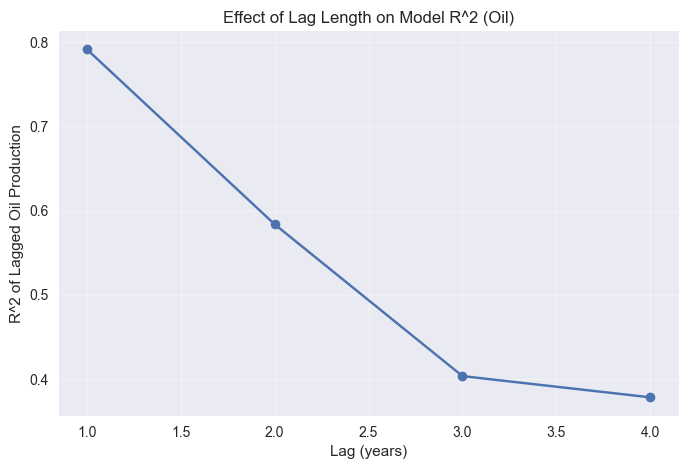

In [88]:
plot_df = comparison_table.dropna(subset=['Lag_Coefficient']).copy()
plot_df['Lag'] = [1,2,3,4]

plt.figure(figsize=(8,5))
plt.errorbar(
    plot_df['Lag'],
    plot_df['R_squared'],
    yerr=plot_df['Lag_SE'],
    fmt='-o',
    capsize=5
)

plt.title("Effect of Lag Length on Model R^2 (Oil)")
plt.xlabel("Lag (years)")
plt.ylabel("R^2 of Lagged Oil Production")
plt.grid(alpha=0.3)
plt.show()

In [75]:
XX1 = lag_df[['Gas_lag1']]
XX1 = sm.add_constant(XX1)
y  = lag_df['Gas (Mcf)']

model1 = sm.OLS(y, XX1).fit()
print("\n===== LAG-1 MODEL =====")
print(model1.summary())


===== LAG-1 MODEL =====
                            OLS Regression Results                            
Dep. Variable:              Gas (Mcf)   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.664
Method:                 Least Squares   F-statistic:                 2.715e+05
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:04:53   Log-Likelihood:            -1.1211e+06
No. Observations:              137681   AIC:                         2.242e+06
Df Residuals:                  137679   BIC:                         2.242e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        207.6691      

In [76]:
XX2 = lag_df[['Gas_lag2']]
XX2 = sm.add_constant(XX2)
y  = lag_df['Gas (Mcf)']

model2 = sm.OLS(y, XX2).fit()
print("\n===== LAG-2 MODEL =====")
print(model2.summary())


===== LAG-2 MODEL =====
                            OLS Regression Results                            
Dep. Variable:              Gas (Mcf)   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.591
Method:                 Least Squares   F-statistic:                 1.989e+05
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:04:55   Log-Likelihood:            -1.1346e+06
No. Observations:              137681   AIC:                         2.269e+06
Df Residuals:                  137679   BIC:                         2.269e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        258.6697      

In [77]:
XX3 = lag_df[['Gas_lag3']]
XX3 = sm.add_constant(XX3)
y  = lag_df['Gas (Mcf)']

model3 = sm.OLS(y, XX3).fit()
print("\n===== LAG-3 MODEL =====")
print(model3.summary())


===== LAG-3 MODEL =====
                            OLS Regression Results                            
Dep. Variable:              Gas (Mcf)   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                 1.656e+05
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:04:57   Log-Likelihood:            -1.1417e+06
No. Observations:              137681   AIC:                         2.283e+06
Df Residuals:                  137679   BIC:                         2.283e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        301.9253      

In [78]:
XX4 = lag_df[['Gas_lag4']]
XX4 = sm.add_constant(XX4)
y  = lag_df['Gas (Mcf)']

model4 = sm.OLS(y, XX4).fit()
print("\n===== LAG-4 MODEL =====")
print(model4.summary())


===== LAG-4 MODEL =====
                            OLS Regression Results                            
Dep. Variable:              Gas (Mcf)   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                 1.374e+05
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:04:59   Log-Likelihood:            -1.1484e+06
No. Observations:              137681   AIC:                         2.297e+06
Df Residuals:                  137679   BIC:                         2.297e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        332.2726      

In [79]:
Xall = lag_df[['Gas_lag1','Gas_lag2','Gas_lag3','Gas_lag4']]
Xall = sm.add_constant(Xall)

combined_model = sm.OLS(y, Xall).fit()
print("\n===== COMBINED MODEL (LAG 1, 4, 8, 12) =====")
print(combined_model.summary())

comparison_table = pd.DataFrame({
    "Model": ["Lag 1","Lag 4","Lag 8","Lag 12","Combined"],
    "R_squared": [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared,
        model4.rsquared,
        combined_model.rsquared
    ],
    "AIC": [
        model1.aic,
        model2.aic,
        model3.aic,
        model4.aic,
        combined_model.aic
    ],
    "Lag_Coefficient": [
        model1.params['Gas_lag1'],
        model2.params['Gas_lag2'],
        model3.params['Gas_lag3'],
        model4.params['Gas_lag4'],
        None 
    ],
    "Lag_SE": [
        model1.bse['Gas_lag1'],
        model2.bse['Gas_lag2'],
        model3.bse['Gas_lag3'],
        model4.bse['Gas_lag4'],
        None
    ]
})

print("\n===== MODEL COMPARISON TABLE =====")
print(comparison_table)


===== COMBINED MODEL (LAG 1, 4, 8, 12) =====
                            OLS Regression Results                            
Dep. Variable:              Gas (Mcf)   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                 9.094e+04
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:05:08   Log-Likelihood:            -1.1071e+06
No. Observations:              137681   AIC:                         2.214e+06
Df Residuals:                  137676   BIC:                         2.214e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

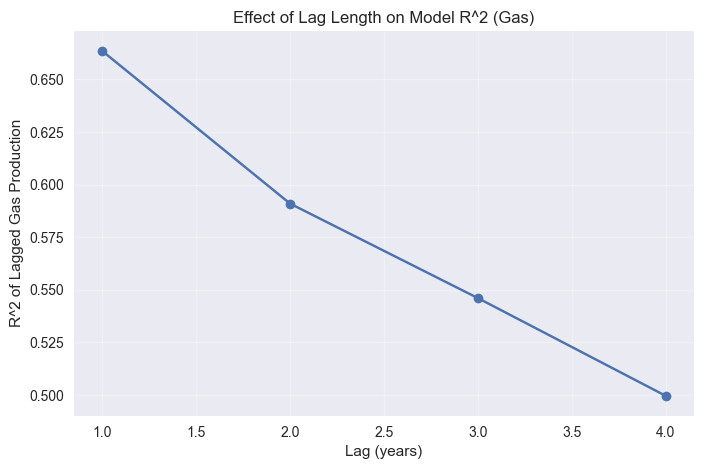

In [80]:
plot_df = comparison_table.dropna(subset=['Lag_Coefficient']).copy()
plot_df['Lag'] = [1,2,3,4]

plt.figure(figsize=(8,5))
plt.errorbar(
    plot_df['Lag'],
    plot_df['R_squared'],
    yerr=plot_df['Lag_SE'],
    fmt='-o',
    capsize=5
)

plt.title("Effect of Lag Length on Model R^2 (Gas)")
plt.xlabel("Lag (years)")
plt.ylabel("R^2 of Lagged Gas Production")
plt.grid(alpha=0.3)
plt.show()